In [1]:
# Imports
import warnings
import numpy as np
import pandas as pd
import pyfixest as pf
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadstat
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.formula.api as smf
import statsmodels.api as sm
from typing import List
from IPython.display import display, Latex, Markdown
pd.options.mode.chained_assignment = None

## 1. Title

## 2. Executive Summary

## 3. Background: Economic Performance

In [2]:
# country-level GDP (mil), population (pop), education, and capital stock from 1950-2019
pwt = pd.read_csv("https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-pwt.csv", sep=',')

In [3]:
alpha = 0.3

In [7]:
def add_series(df):
    df = df.copy()
    df["ynew"] = df["rgdpo"] / df["pop"]
    df["knew"] = df["cn"] / df["pop"]
    df["Anew"] = df["ynew"] / (df["knew"] ** alpha) / (df["hc"] ** (1 - alpha))
    df["lnynew"] = np.log(df["ynew"])
    df["lnknew"] = np.log(df["knew"])
    df["lnAnew"] = np.log(df["Anew"])
    return df

In [8]:
# Czechia + Slovakia
pwt_cz = add_series(pwt[pwt["countrycode"] == "CZE"])
pwt_sk = add_series(pwt[pwt["countrycode"] == "SVK"])

# 1980+
pwt_cz_1980 = pwt_cz[pwt_cz["year"] >= 1980]
pwt_sk_1980 = pwt_sk[pwt_sk["year"] >= 1980]

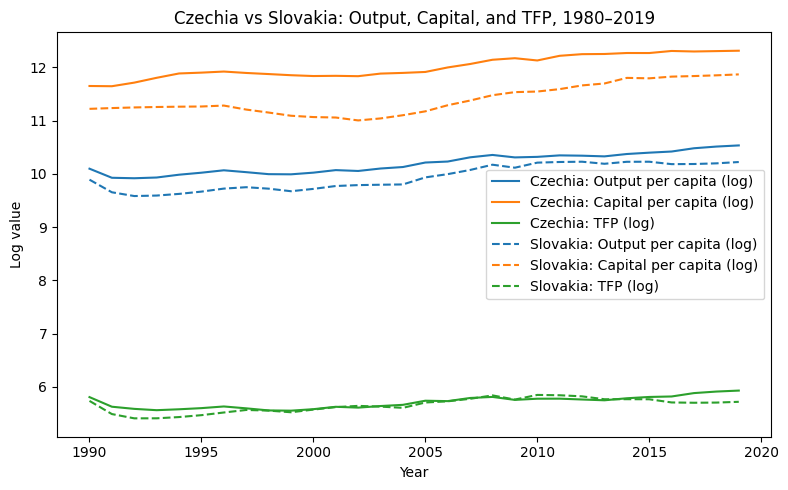

In [10]:
plt.figure(figsize=(8,5))

# Czechia (solid)
line_y_cz, = plt.plot(pwt_cz_1980["year"], pwt_cz_1980["lnynew"],
                      label="Czechia: Output per capita (log)")
line_k_cz, = plt.plot(pwt_cz_1980["year"], pwt_cz_1980["lnknew"],
                      label="Czechia: Capital per capita (log)")
line_A_cz, = plt.plot(pwt_cz_1980["year"], pwt_cz_1980["lnAnew"],
                      label="Czechia: TFP (log)")

# Slovakia (dashed) — same colors as Czechia lines
plt.plot(pwt_sk_1980["year"], pwt_sk_1980["lnynew"],
         linestyle="--", color=line_y_cz.get_color(),
         label="Slovakia: Output per capita (log)")
plt.plot(pwt_sk_1980["year"], pwt_sk_1980["lnknew"],
         linestyle="--", color=line_k_cz.get_color(),
         label="Slovakia: Capital per capita (log)")
plt.plot(pwt_sk_1980["year"], pwt_sk_1980["lnAnew"],
         linestyle="--", color=line_A_cz.get_color(),
         label="Slovakia: TFP (log)")

plt.xlabel("Year")
plt.ylabel("Log value")
plt.title("Czechia vs Slovakia: Output, Capital, and TFP, 1980–2019")
plt.legend()
plt.tight_layout()
plt.show()

Since the Velvet Revolution in 1989, Czechia's TFP has not changed significantly even though the country's GDP pc and capital pc increased over the years. Although Czechia's economy is often portrayed as a strong competitor to its former sister nation Slovakia, for much of the countries' history, TFP was very similar. Only after 2015, did some divergence occur.

## 4a. Export and Comparative Advantage Assessment

In [37]:
# countries’ exports by industry-year from 1995-2022
industryflows = pd.read_csv("https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-industryflows.csv", sep=',')

In [ ]:
industryflowscze = industryflows[industryflows['iso_o'] == 'CZE']

In [39]:
industryflowscze = industryflowscze[(industryflowscze['year'] == 2000) | (industryflowscze['year'] == 2021)]

In [40]:
industryflowscze['value_tot'] = industryflowscze['value'].sum()
industryflowscze['value_wd_tot'] = industryflowscze['value_wd'].sum()
industryflowscze['sh_hs2'] = industryflowscze['value'] / industryflowscze['value_wd']
industryflowscze['sh_wd'] = industryflowscze['value_tot'] / industryflowscze['value_wd_tot']
industryflowscze['rca'] = industryflowscze['sh_hs2'] / industryflowscze['sh_wd']

In [41]:
industryflowscze['rca_change'] = industryflowscze.groupby('hs2')['rca'].diff()

In [42]:
rca_levels = industryflowscze.pivot(index='hs2', columns='year', values='rca').reset_index()
rca_levels = rca_levels.rename(columns={2000: 'rca_2000', 2021: 'rca_2021'})

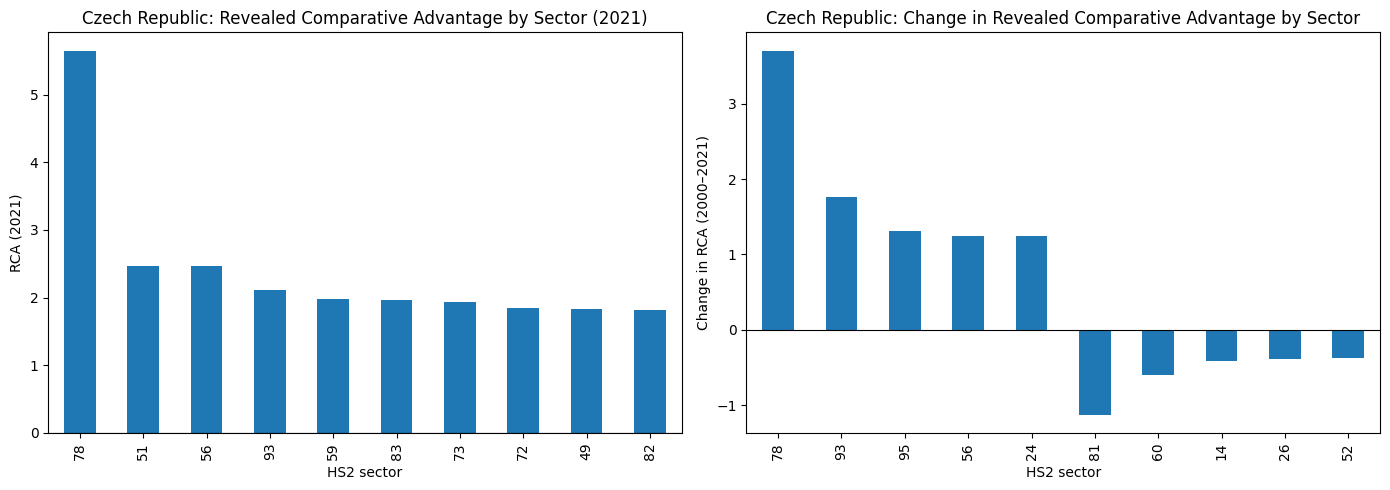

In [21]:
# Top sectors by RCA
top = industryflowscze.groupby('hs2')['rca'].last().sort_values(ascending=False).head(10)
top = top.reset_index().merge(rca_levels, on='hs2')

# Top 10 by RCA increase
top10 = industryflowscze.groupby('hs2')['rca_change'].last().sort_values(ascending=False).head(5)

# Bottom 5 by RCA change
bottom5 = industryflowscze.groupby('hs2')['rca_change'].last().sort_values().head(5)

# Combine and drop any duplicates
sel = pd.concat([top10, bottom5]).reset_index().drop_duplicates(subset='hs2')

# Merge with RCA levels if you still need them
sel = sel.merge(rca_levels, on='hs2', how='left')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- Left: Top sectors by RCA (2021)
top.plot(x='hs2', y='rca_2021', kind='bar', ax=ax1, legend=False)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_xlabel('HS2 sector')
ax1.set_ylabel('RCA (2021)')
ax1.set_title('Czech Republic: Revealed Comparative Advantage by Sector (2021)')

# --- Right: Change in RCA
sel.plot(x='hs2', y='rca_change', kind='bar', ax=ax2, legend=False)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('HS2 sector')
ax2.set_ylabel('Change in RCA (2000–2021)')
ax2.set_title('Czech Republic: Change in Revealed Comparative Advantage by Sector')

plt.tight_layout()
plt.show()

Czechia's areas with the strongest comparative advantage in 2021 lay in lead and articles thereof; wool and animal hair; and wadding, felt, and nonwovens. Compared to 2000, Czechia improved its RCA most in lead and articles thereof; arms and ammunition; and toys, games, and sports equipment. Meanwhile, it has lost the most in base metal nesoi; knitted or crocheted fabrics; and vegetable plaiting materials and vegetable products. These findings are surprising considering Czechia's strong reliance on the automotive industry and production of heavy machinery.

## 4b. Imagining Global Trade without the WTO

In [45]:
# # bilateral trade between countries, aggregated across all industries, for 1948-2020
gravity = pd.read_csv("https://raw.githubusercontent.com/akhandelwal8/globaleconomics/refs/heads/main/midterm/final-gravity.csv", sep=',')

In [46]:
gravitycze = gravity[(gravity['iso_o'] == 'CZE') & (gravity['year'] == 2020)]

In [47]:
gravitycze['log_value'] = np.log(gravitycze['value'] + 1)
gravitycze['log_distw'] = np.log(gravitycze['distw'])
gravitycze['log_gdp_d'] = np.log(gravitycze['gdp_d'])
gravitycze['log_scaled_sci_2021'] = np.log(gravitycze['scaled_sci_2021'])

In [51]:
# Regression
model1 = smf.ols('log_value ~ wto_o + log_distw + log_gdp_d + contig + comlang_ethno +' \
            'comleg_posttrans + rta + wto_d + diplo_disagreement + log_scaled_sci_2021 + eu_d',
            data=gravitycze).fit(cov_type="HC1")

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:              log_value   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     2385.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          1.80e-155
Time:                        20:47:38   Log-Likelihood:                -237.56
No. Observations:                 155   AIC:                             495.1
Df Residuals:                     145   BIC:                             525.6
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -4.3863    

c:\Users\nepoz\yale\spring26\economics-for-global-affairs\economics-for-global-affairs\venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 10
  warnings.warn('covariance of constraints does not have full '


Although in theory the WTO would likely have significant negative impacts on Czechia's exports, the gravity model does not ascribe much importance to Czechia's membership in the WTO and the membership of its trade partners. This is likely caused by insufficient amount of the Czechia's significant trade partners that are not in the WTO. Simply put, there is insufficient counterfactual.

## 4c. Barriers to Trade

According to the gravity model above, Czechia does not have many actionable possibilities for increasing its exports to the world. Most of the indicators that could be reasonably affected by policies are not significant enough in the model to provide approximate estimations on the strength and direction of their impact on trade. Two possible areas that Czechia could tackle in case of a WTO disintegration would be (i) improving the interconnectedness of legal systems with its trade partners and (ii) improving the social interconnectedness between its citizens and the citizens of the trade partners (e.g., by promoting cultural exchange programs).

## 5. Recommendations